In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../dataset/cleaned_dataset.csv')
df.head()

,manufacturer,model,type,drive_type,fuel_type,color,battery_kwh,range_km,charging_time_hr,fast_charging,...,city,seats,price_usd,efficiency_score,acceleration_0_100_kmph,top_speed_kmph,warranty_years,cargo_space_liters,safety_rating,target_high_efficiency
0,BYD,Model S,Coupe,FWD,Electric,Blue,84.93,464.06,0.85,1,...,Shanghai,7,32213.0,5.394897,5.84,136.00,3,248.9,3.3,1
1,Lucid,EV6,Sedan,AWD,Electric,Blue,65.14,345.36,2.03,1,...,Tokyo,7,31125.0,5.067074,3.86,149.34,5,504.3,3.6,1
2,Volkswagen,EV6,SUV,FWD,Hybrid,White,22.75,104.25,0.22,1,...,Oslo,5,15674.0,5.057602,2.85,275.80,5,424.9,4.2,1
3,BMW,Ioniq,Sedan,AWD,Hybrid,Black,71.72,341.74,0.48,0,...,Vancouver,2,24044.0,4.826029,3.78,130.41,8,398.5,4.9,0
4,Volkswagen,Model 3,Truck,AWD,Hybrid,Green,62.99,338.16,0.79,1,...,Shenzhen,4,29567.0,5.222624,7.07,253.31,7,411.4,3.4,1


In [3]:
df['target_high_efficiency'].value_counts(normalize = True)

target_high_efficiency
0    0.500153
1    0.499847
Name: proportion, dtype: float64

In [4]:
df.isnull().sum()

manufacturer               0
model                      0
type                       0
drive_type                 0
fuel_type                  0
color                      0
battery_kwh                0
range_km                   0
charging_time_hr           0
fast_charging              0
release_year               0
country                    0
city                       0
seats                      0
price_usd                  0
efficiency_score           0
acceleration_0_100_kmph    0
top_speed_kmph             0
warranty_years             0
cargo_space_liters         0
safety_rating              0
target_high_efficiency     0
dtype: int64

In [5]:
df.describe()

,battery_kwh,range_km,charging_time_hr,fast_charging,release_year,seats,price_usd,efficiency_score,acceleration_0_100_kmph,top_speed_kmph,warranty_years,cargo_space_liters,safety_rating,target_high_efficiency
count,248730.000000,248730.000000,248730.000000,248730.000000,248730.00000,248730.000000,248730.000000,248730.000000,248730.000000,248730.000000,248730.000000,248730.000000,248730.000000,248730.000000
mean,75.017593,375.135210,1.071692,0.498822,2018.51174,4.799650,30515.659518,4.999747,6.249567,199.994350,6.598842,449.625036,4.000114,0.499847
std,19.712752,108.241353,0.654447,0.500000,4.03314,1.721548,7095.820189,0.764214,2.166481,46.226291,2.419392,99.070187,0.578896,0.500001
min,0.430000,1.990000,0.010000,0.000000,2012.00000,2.000000,10662.000000,2.194368,2.500000,120.000000,3.000000,31.400000,3.000000,0.000000
25%,61.550000,299.570000,0.610000,0.000000,2015.00000,4.000000,25583.250000,4.448934,4.370000,159.940000,5.000000,382.500000,3.500000,0.000000
50%,74.990000,370.380000,0.860000,0.000000,2019.00000,5.000000,30502.000000,4.999699,6.250000,199.970000,7.000000,450.200000,4.000000,0.000000
75%,88.470000,445.890000,1.330000,1.000000,2022.00000,6.000000,35453.000000,5.551981,8.130000,239.980000,8.000000,517.300000,4.500000,1.000000
max,150.000000,869.200000,3.370000,1.000000,2025.00000,7.000000,50372.000000,8.000000,10.000000,280.000000,10.000000,682.700000,5.000000,1.000000


In [6]:
df.dtypes

manufacturer                object
model                       object
type                        object
drive_type                  object
fuel_type                   object
color                       object
battery_kwh                float64
range_km                   float64
charging_time_hr           float64
fast_charging                int64
release_year                 int64
country                     object
city                        object
seats                        int64
price_usd                  float64
efficiency_score           float64
acceleration_0_100_kmph    float64
top_speed_kmph             float64
warranty_years               int64
cargo_space_liters         float64
safety_rating              float64
target_high_efficiency       int64
dtype: object

In [7]:
df.describe(include='object')

,manufacturer,model,type,drive_type,fuel_type,color,country,city
count,248730,248730,248730,248730,248730,248730,248730,248730
unique,10,11,6,3,2,8,10,21
top,Chevrolet,i3,Sedan,RWD,Electric,Green,UK,Oslo
freq,25170,22786,41761,83055,124670,31310,25020,24947


In [8]:
# splitting dataset before performing EDA
from sklearn.model_selection import train_test_split

TRAIN_SIZE = 0.70
TEST_SIZE = 0.15
VAL_SIZE = 0.15

train_val, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42, stratify = df['target_high_efficiency'])

adjusted_val_size = VAL_SIZE/(TRAIN_SIZE+VAL_SIZE)

train_df, val_df = train_test_split(train_val, test_size=adjusted_val_size, random_state=42, stratify = train_val['target_high_efficiency'])

print(f"  Total samples: {len(df):,}")
print(f"  Training:   {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Validation: {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:       {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

  Total samples: 248,730
  Training:   174,110 (70.0%)
  Validation: 37,310 (15.0%)
  Test:       37,310 (15.0%)


In [9]:
def correlations(df, target_col = 'target_high_efficiency'):
    num_col = df.select_dtypes(include=[np.number]).columns.tolist()
    corr_matrix = df[num_col].corr()
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending = False)

    print('Features Correlation with Target -')
    print(target_corr)

    # highly correlated features 
    high_corr = target_corr[abs(target_corr)>0.1].index.tolist()
    print('\nHighly correlated features -')
    for f in high_corr:
        print(f'-{f}: {target_corr[f]:.3f}')

    # Multicollinearity check
    multi_pair = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.8:
                multi_pair.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    if multi_pair:
        print('\nHigh multicollinearity b/w the following -')
        for feat1, feat2, corr_val in multi_pair:
            print(f"  - {feat1} <-> {feat2}: {corr_val:.3f}")
    else:
        print('\nNo severe multicollinearity detected')

    # Correlation Heatmap
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap = 'coolwarm')
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()

    return target_corr, high_corr, multi_pair

Features Correlation with Target -
efficiency_score           0.816771
range_km                   0.265014
top_speed_kmph             0.004267
warranty_years             0.003879
cargo_space_liters         0.002572
fast_charging              0.002424
safety_rating              0.000526
charging_time_hr          -0.000097
seats                     -0.000215
acceleration_0_100_kmph   -0.000796
release_year              -0.001273
battery_kwh               -0.003144
price_usd                 -0.004636
Name: target_high_efficiency, dtype: float64

Highly correlated features -
-efficiency_score: 0.817
-range_km: 0.265

High multicollinearity b/w the following -
  - battery_kwh <-> range_km: 0.910
  - battery_kwh <-> price_usd: 0.823
  - efficiency_score <-> target_high_efficiency: 0.817


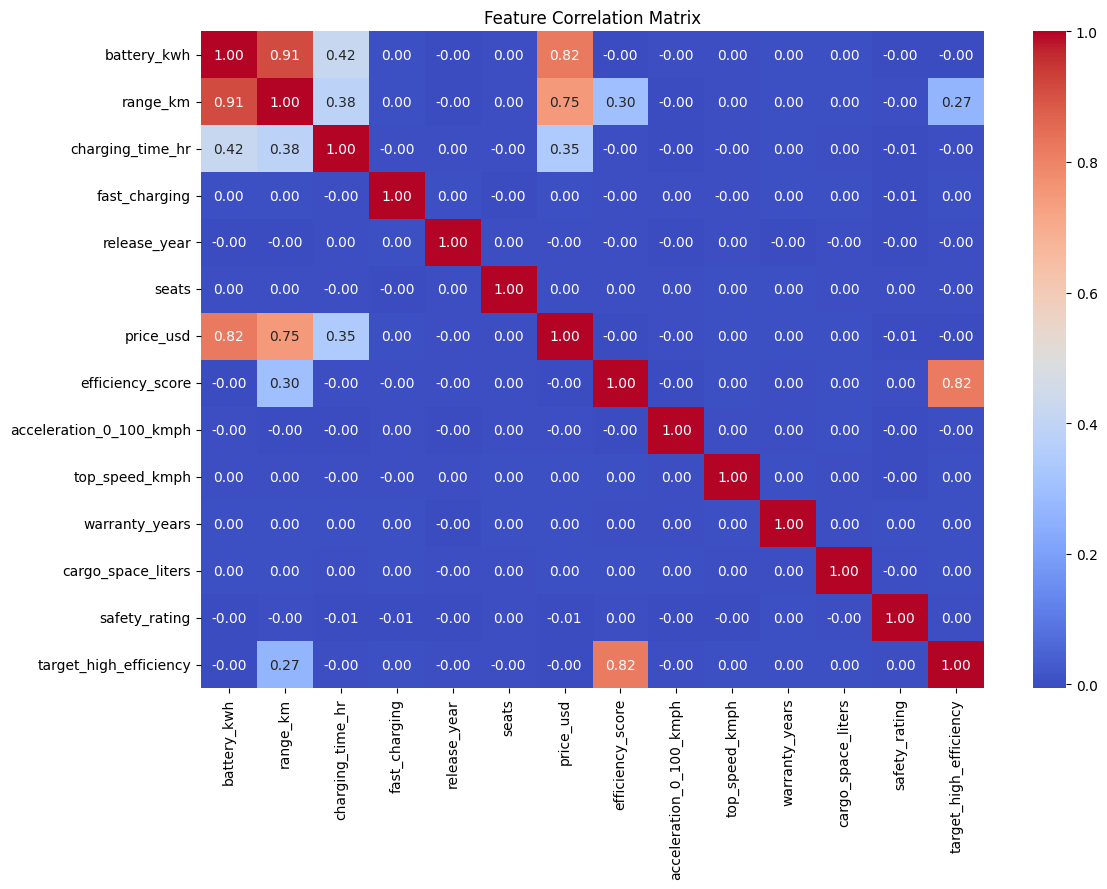

In [10]:
target_corr, high_corr, multi_pair = correlations(train_df)

**Dropping efficiency_score and battery_kwh (high correlation)** 
**Dropping top_speed_kmph, warranty_years, cargo_space_liters, fast_charging, safety_rating, charging_time_hr, seats, acceleration_0_100_kmph, release_year (very low correlation)**
**Dropping manufacturer, model, city, color (high cardinality)**

In [11]:
def engineer_features(df):
    
    df_eng = df.copy()
    
    # Core efficiency metrics
    df_eng['range_efficiency'] = df_eng['range_km'] / (df_eng['battery_kwh'] + 0.001)
    df_eng['battery_range_ratio'] = df_eng['battery_kwh'] / (df_eng['range_km'] + 0.001)
    df_eng['charging_speed'] = df_eng['battery_kwh'] / (df_eng['charging_time_hr'] + 0.001)
    df_eng['power_indicator'] = 100 / (df_eng['acceleration_0_100_kmph'] + 0.001)
    df_eng['speed_efficiency'] = df_eng['range_km'] / (df_eng['top_speed_kmph'] + 0.001)
    df_eng['vehicle_age'] = 2026 - df_eng['release_year']
    df_eng['price_per_kwh'] = df_eng['price_usd'] / (df_eng['battery_kwh'] + 0.001)
    df_eng['range_per_seat'] = df_eng['range_km'] / (df_eng['seats'] + 0.001)
    df_eng['is_electric'] = (df_eng['fuel_type'] == 'Electric').astype(int)
    df_eng['has_fast_charging'] = df_eng['fast_charging'].astype(int)
    
    return df_eng

In [12]:
train_df = engineer_features(train_df)
val_df = engineer_features(val_df)
test_df = engineer_features(test_df)

Features Correlation with Target -
efficiency_score           0.816771
range_efficiency           0.668036
range_km                   0.265014
speed_efficiency           0.194883
range_per_seat             0.126992
is_electric                0.005308
top_speed_kmph             0.004267
warranty_years             0.003879
power_indicator            0.002698
cargo_space_liters         0.002572
fast_charging              0.002424
has_fast_charging          0.002424
vehicle_age                0.001273
safety_rating              0.000526
charging_time_hr          -0.000097
seats                     -0.000215
price_per_kwh             -0.000641
acceleration_0_100_kmph   -0.000796
release_year              -0.001273
charging_speed            -0.002917
battery_kwh               -0.003144
price_usd                 -0.004636
battery_range_ratio       -0.663209
Name: target_high_efficiency, dtype: float64

Highly correlated features -
-efficiency_score: 0.817
-range_efficiency: 0.668
-range_km: 0

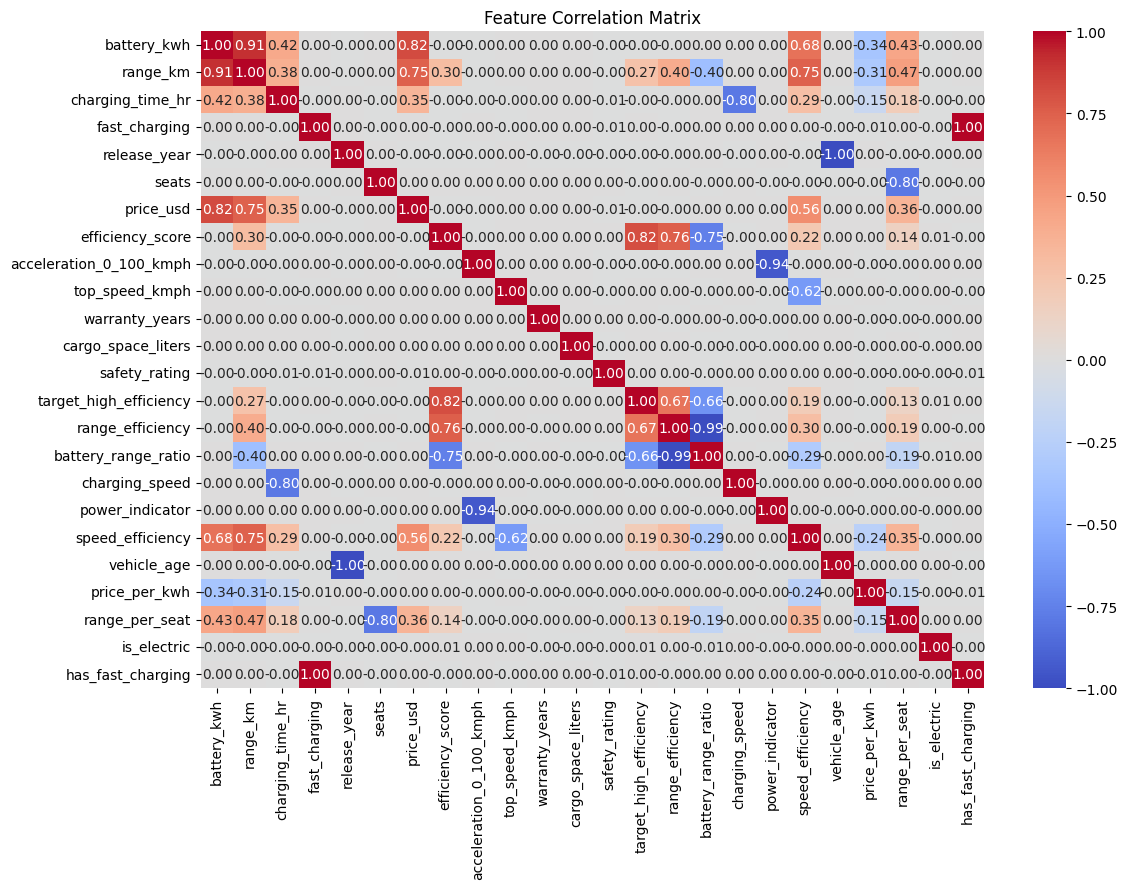

In [13]:
target_corr, high_corr, multi_pair = correlations(train_df)

**From engineered features keeping only range_efficiency, speed_efficiency, range_per_seat**

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

class DataPreprocessor:
    def __init__(self, num_col, cat_col, target_col='target_high_efficiency'):
        self.num_col = num_col
        self.cat_col = cat_col
        self.target_col = target_col

        self.scaler = StandardScaler()
        self.ohe = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

        self.is_fitted = False

    def fit(self, train_df):
        # Store statistics from TRAIN only
        self.num_median = {
            col: train_df[col].median() for col in self.num_col
        }
        self.cat_mode = {
            col: train_df[col].mode()[0] for col in self.cat_col
        }

        # Prepare training features
        X_train = self._prepare_base_features(train_df)

        # Fit encoders
        self.scaler.fit(X_train[self.num_col])
        self.ohe.fit(X_train[self.cat_col].astype(str))

        self.is_fitted = True
        return self

    def transform(self, df, split_name=''):
        if not self.is_fitted:
            raise ValueError("Must call fit() before transform()")

        X = self._prepare_base_features(df)

        # Scale numerical features
        X_num = pd.DataFrame(
            self.scaler.transform(X[self.num_col]),
            columns=self.num_col,
            index=X.index
        )

        # One-hot encode categorical features
        X_cat = pd.DataFrame(
            self.ohe.transform(X[self.cat_col].astype(str)),
            columns=self.ohe.get_feature_names_out(self.cat_col),
            index=X.index
        )

        # Combine
        X_final = pd.concat([X_num, X_cat], axis=1)

        if split_name:
            print(f"Transformed {split_name} set: {X_final.shape}")

        return X_final

    def _prepare_base_features(self, df):
        X = df[self.num_col + self.cat_col].copy()

        for col in self.num_col:
            X[col] = X[col].fillna(self.num_median[col])

        for col in self.cat_col:
            X[col] = X[col].fillna(self.cat_mode[col]).astype(str)

        return X

In [16]:
train_df.head()

,manufacturer,model,type,drive_type,fuel_type,color,battery_kwh,range_km,charging_time_hr,fast_charging,...,range_efficiency,battery_range_ratio,charging_speed,power_indicator,speed_efficiency,vehicle_age,price_per_kwh,range_per_seat,is_electric,has_fast_charging
57640,Kia,Air,Hatchback,FWD,Hybrid,Grey,62.58,296.28,0.87,1,...,4.734344,0.211218,71.848450,16.471751,2.344525,6,363.017529,59.244151,0,1
155735,Chevrolet,EV6,Sedan,AWD,Electric,Grey,70.59,324.62,0.51,1,...,4.598603,0.217454,138.140900,10.287008,1.525750,3,456.687113,162.228886,1,1
147765,Volkswagen,Air,Coupe,FWD,Electric,Green,80.15,375.59,0.57,1,...,4.686030,0.213397,140.367776,26.239832,1.359991,2,427.892353,75.102979,1,1
199835,Ford,Model S,Crossover,FWD,Hybrid,Blue,99.49,442.23,3.08,1,...,4.444925,0.224973,32.291464,29.841838,3.282805,9,396.337357,63.166690,0,1
147610,Volkswagen,Model X,Hatchback,AWD,Hybrid,Yellow,93.82,381.33,1.67,0,...,4.064442,0.246033,56.146020,34.118048,2.314162,12,367.401754,54.467933,0,0


In [17]:
target_col = 'target_high_efficiency'

feature_cols = [
    'range_km', 'battery_kwh', 'price_usd',
    'range_efficiency', 'speed_efficiency', 'range_per_seat',
    'type', 'drive_type', 'fuel_type', 'country'
]

X_train_df = train_df[feature_cols]
y_train = train_df[target_col]

X_val_df = val_df[feature_cols]
y_val = val_df[target_col]

X_test_df = test_df[feature_cols]
y_test = test_df[target_col]

In [18]:
cat_col = X_train_df.select_dtypes(include=['object']).columns.tolist()
num_col = X_train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Categorical Columns: {len(cat_col)}')
print(f'Numerical Columns: {len(num_col)}')

Categorical Columns: 4
Numerical Columns: 6


In [19]:
preprocessor = DataPreprocessor(num_col, cat_col)
preprocessor.fit(X_train_df)

X_train = preprocessor.transform(X_train_df, 'Train')
X_val = preprocessor.transform(X_val_df, 'Validation')
X_test = preprocessor.transform(X_test_df, 'Test')

Transformed Train set: (174110, 27)
Transformed Validation set: (37310, 27)
Transformed Test set: (37310, 27)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [21]:
def evaluation(results, model_name, y_train, train_pred, train_proba, y_val, val_pred, val_proba, cv_scores):
    results[model_name] = {
                'train_accuracy': accuracy_score(y_train, train_pred),
                'train_roc_auc': roc_auc_score(y_train, train_proba),
                'val_accuracy': accuracy_score(y_val, val_pred),
                'val_roc_auc': roc_auc_score(y_val, val_proba),
                'val_precision': precision_score(y_val, val_pred),
                'val_recall': recall_score(y_val, val_pred),
                'val_f1': f1_score(y_val, val_pred),
                'cv_roc_auc_mean': cv_scores.mean(),
                'cv_roc_auc_std': cv_scores.std(),
                'val_predictions': val_pred,
                'val_probabilities': val_proba,
                'overfitting_gap': abs(roc_auc_score(y_train, train_proba) - roc_auc_score(y_val, val_proba))
            }
    return results

In [22]:
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val, results, model_name="Model", cv_folds=5, random_state=42):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_proba = model.predict_proba(X_train)[:, 1]
    val_proba = model.predict_proba(X_val)[:, 1]

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")

    results = evaluation(results, model_name, y_train, train_pred, train_proba, y_val, val_pred, val_proba, cv_scores)
    
    return model, results

In [23]:
results = {}

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=50,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1)
}

trained_models = {}

for name, model in models.items():
    trained_model, results = train_and_evaluate_model(
        model=model,
        model_name=name,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        results=results
    )
    trained_models[name] = trained_model

In [24]:
pd.DataFrame.from_dict(results).T

,train_accuracy,train_roc_auc,val_accuracy,val_roc_auc,val_precision,val_recall,val_f1,cv_roc_auc_mean,cv_roc_auc_std,val_predictions,val_probabilities,overfitting_gap
Logistic Regression,0.805376,0.885668,0.807746,0.886741,0.807932,0.807282,0.807607,0.885582,0.001822,"[0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...","[0.08876390490596402, 0.09980155209041912, 0.9...",0.001072
Random Forest,0.807128,0.889581,0.807505,0.88422,0.814113,0.796826,0.805376,0.882536,0.001829,"[0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...","[0.14284782597976087, 0.12993329979315443, 0.8...",0.00536
XGBoost,0.809201,0.89188,0.80654,0.88605,0.808862,0.802617,0.805728,0.884764,0.001932,"[0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...","[0.082228646, 0.10217128, 0.92801267, 0.768114...",0.00583
LightGBM,0.807708,0.889665,0.806111,0.886277,0.809031,0.801223,0.805108,0.884964,0.001906,"[0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...","[0.07636394922233367, 0.10402116231346341, 0.9...",0.003388


In [25]:
for model_name, metrics in results.items():
    metrics.pop("val_predictions", None)
    metrics.pop("val_probabilities", None)

In [26]:
def evaluate_on_test(results, model_name, model, X_test, y_test):
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    results[model_name] = {
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_roc_auc': roc_auc_score(y_test, test_proba),
        'test_precision': precision_score(y_test, test_pred),
        'test_recall': recall_score(y_test, test_pred),
        'test_f1': f1_score(y_test, test_pred),
        'test_predictions': test_pred,
        'test_probabilities': test_proba
    }

    return results

In [27]:
results_test = {}
for model_name, model in trained_models.items():
    results_test = evaluate_on_test(
        results=results_test,
        model_name=model_name,
        model=model,
        X_test=X_test,
        y_test=y_test
    )

In [28]:
pd.DataFrame.from_dict(results_test).T

,test_accuracy,test_roc_auc,test_precision,test_recall,test_f1,test_predictions,test_probabilities
Logistic Regression,0.803431,0.88436,0.804609,0.80133,0.802966,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, ...","[0.46437382409444083, 0.961845336816068, 0.436..."
Random Forest,0.803779,0.881334,0.811551,0.791142,0.801216,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, ...","[0.478988546020286, 0.9091892250721435, 0.4017..."
XGBoost,0.803833,0.884061,0.808081,0.796772,0.802387,"[1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, ...","[0.5202079, 0.9724062, 0.4832879, 0.057961408,..."
LightGBM,0.803216,0.884052,0.80774,0.7957,0.801675,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, ...","[0.47772972719606543, 0.9697018907941404, 0.47..."


In [29]:
for model_name, metrics in results_test.items():
    metrics.pop("test_predictions", None)
    metrics.pop("test_probabilities", None)

In [30]:
# val_df

In [31]:
val_df = pd.DataFrame.from_dict(results).T
best_model_name = val_df['val_roc_auc'].idxmax()
best_model_name

'Logistic Regression'

In [32]:
import pickle
best_model = trained_models[best_model_name]

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("../models/preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

In [33]:
import json
from datetime import datetime

experiment_metadata = {
    "experiment_name": f"ev_efficiency_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "best_model": best_model_name,
    "feature_strategy": "optimal",
    "feature_names": feature_cols,
    "data_splits": {
        "train": 0.7,
        "val": 0.15,
        "test": 0.15
    },
    "validation_results": results,
    "test_results": results_test
}

def convert_np(obj):
    import numpy as np
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj

with open("../outputs/experiment_metadata.json", "w") as f:
    json.dump(experiment_metadata, f, default=convert_np, indent=2)